# Tables gen (.tex)

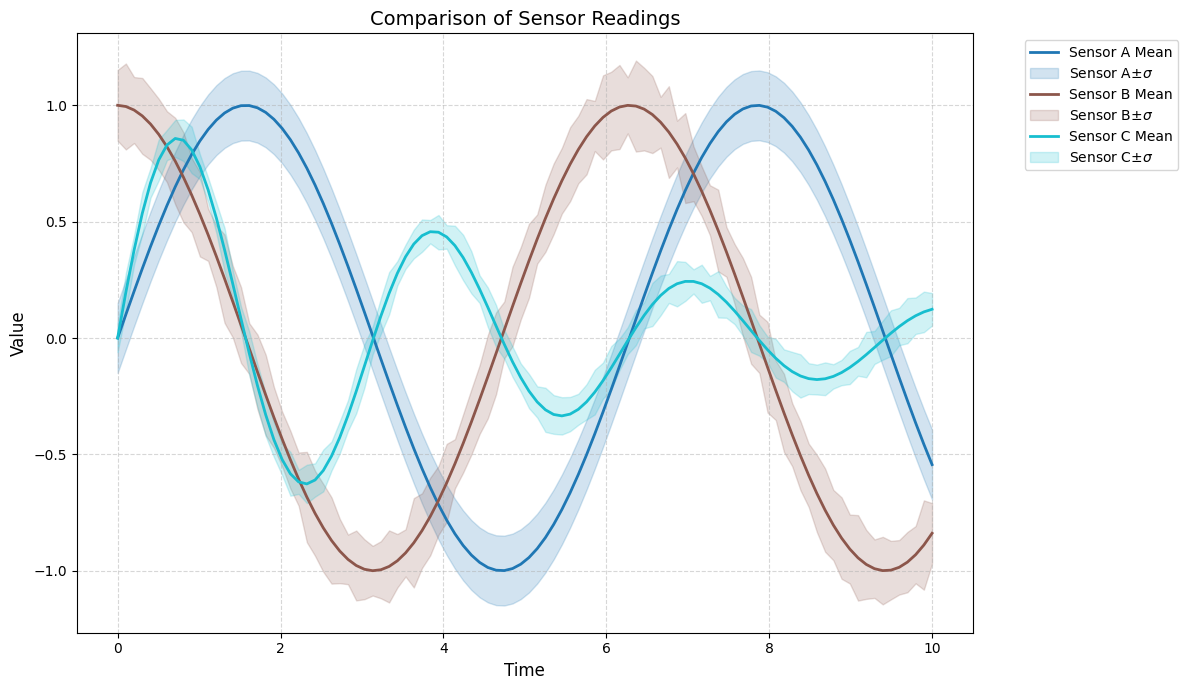

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def plot_multi_series(time, series_dict, title="Multi-Series Comparison"):
    """
    Plots multiple mean lines with shaded standard deviation bands.
    
    Args:
        time (array): The x-axis values (time instants).
        series_dict (dict): A dictionary where keys are labels and values 
                            are tuples of (mean_array, std_dev_array).
        title (str): Title of the plot.
    """
    plt.figure(figsize=(12, 7))
    
    # Use a color cycle so each line gets a distinct color
    colors = plt.cm.tab10(np.linspace(0, 1, len(series_dict)))

    for (label, (mean, std)), color in zip(series_dict.items(), colors):
        # Plot mean line
        plt.plot(time, mean, label=f"{label} Mean", color=color, lw=2, marker="")
        
        # Plot shaded error band
        plt.fill_between(time, mean - std, mean + std, 
                         color=color, alpha=0.2, label=label+r"$\pm \sigma$")

    plt.title(title, fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left") # Legend outside for clarity
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
t = np.linspace(0, 10, 100)

# Creating dummy data for three different series
data = {
    "Sensor A": (np.sin(t), 0.15 * np.ones(100)),
    "Sensor B": (np.cos(t), 0.1 + 0.1 * np.random.rand(100)),
    "Sensor C": (np.exp(-t/5) * np.sin(t*2), 0.05 + 0.05 * np.random.rand(100))
}

plot_multi_series(t, data, title="Comparison of Sensor Readings")

In [2]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset, Subset
from torch import Tensor
from data_utils import X, U, TIMES, include_time_in_input, compute_prediction_difference, compute_prediction, extract_targets, extract_TensorDataset, extract_boundary
from plot_utils import plot_loss_comp, plot_model_stats, print_model_info, plot_points_grid, plot_model_stats_grid, print_model_performances, plot_model_performances, plot_points, get_animation, plot_performance_comparison, plot_loss
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm
import numpy as np
import pandas as pd
# ----------------------
PDE = "AdvectionReactionDiffusion/AllenCahn"

SAMPLES = [0, 1, 2, 3, 4]

N_SOURCES = 5

GENERATION_BC = "Neumann" # Dirichlet Neumann

N_TIME_SAMPLES = 10
TRAIN_TIME_INDEXESS = [[0, i-1, i] for i in range(1, 10, 2)] #[[i-1, i] for i in range(1, 10, 2)] #[[i] for i in range(1, 10)]
TIME_RESOLUTION = 1
TIME_SAMPLING = "Const" # Const Log

ACTUAL_MODE = "PINN" # Output Output+PINN Output+Derivative Output+Derivative+Hessian 
N_EPOCHS = 200
LR_MODE = "CosAnn" # CosAnn ExpDec

ACTUAL_MODE0 = "PINN"
N_EPOCHS0 = N_EPOCHS
LR_MODE0 = LR_MODE

N_EPOCHS_FULL = 400

#SHAPE = {"shape": "circle", "cell_size": 0.02, "center": [0.0, 0.0], "radius": 1.0}
SHAPE = {"shape": "rectangle"}

#SHAPE0 = {"shape": "circle", "cell_size": 0.02, "center": [0.0, 0.0], "radius": 1.0}
SHAPE0 = {"shape": "rectangle"}

BC_MODE = "Global" # Local
IC_MODE = "Separated" # Separated Excluded Joined
TRAIN_BC = "Neumann" # Dirichlet Neumann

BC_MODE0 = BC_MODE
IC_MODE0 = IC_MODE

IC_PARAMS_IN_INPUT = False
PDE_PARAMS_IN_INPUT = False

DWA_MODE = "Std"
CLIP_GRAD = True

LONG_TERM_MEMORY = True

FROM_SCRATCH = False
FINE_TUNING = True

# ----------------------

N_TASKS = len(TRAIN_TIME_INDEXESS)

if not CLIP_GRAD:
    CLIP = "NoGradClip"
else:
    CLIP = "GradClip"
    
DIRS = [f"{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_DT{TIME_RESOLUTION}_{GENERATION_BC}BcGeneration/ICD{i}" for i in SAMPLES]
DIR0S = ["" for _ in DIRS]
s = "VaryIC_VaryD"
for i in range(len(DIRS)):
    if PDE_PARAMS_IN_INPUT and IC_PARAMS_IN_INPUT:
        DIRS[i] += f"/PDE_IC_params_in_input"
    elif PDE_PARAMS_IN_INPUT:
        DIRS[i] += f"/PDE_params_in_input"
    elif IC_PARAMS_IN_INPUT:
        DIRS[i] += f"/IC_params_in_input"
    else:
        DIRS[i] += f"/No_params_in_input"

    DIR0S[i] = DIRS[i] + f"/{SHAPE0['shape']}/T0"
    DIRS[i] += f"/{SHAPE['shape']}"

if LONG_TERM_MEMORY:
    MEMORY = "LongMemory"
else:
    MEMORY = "ShortMemory"

s2 = s
if N_SOURCES is not None:
    s += f"/{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_0-9"
    s2 += f"/{N_SOURCES}sources_{TIME_SAMPLING}TimeStep_10-19"
else:
    s += f"/{TIME_SAMPLING}TimeStep_0-9"
    s2 += f"/{TIME_SAMPLING}TimeStep_10-19"

s += f"/rep0"
s2 += f"/rep0"

DATA = f"data/{GENERATION_BC}BC/{SHAPE['shape']}/{s}"
DATA2 = f"data/{GENERATION_BC}BC/{SHAPE['shape']}/{s2}"

full_dataset = None
dev_dataset = None
train_dataset = None
val_dataset = None
intra_test_dataset = None
inter_test_dataset = None

YELLOW = ["#FFF3D1", "#FFE7A5", "#FFD483", "#B36430"]
ORANGE = ["#FFE6B8", "#FFD8B8", "#FFBF8A", "#D15E00", "#A34900"]
PURPLE = ["#EDE6FF", "#C9BCEA", "#A48BDE", "#6500A3"]
BROWN = ["#E8CECE", "#D9AFAF", "#BC7171", "#8E4343"]
RED = ["#FFD0D0", "#D59999", "#D17878", "#8E4343"]
BLUE = ["#E6E9FF", "#B8C2FF", "#687FFF", "#4D5AD0"]#"#8799FF"
GRAY = ["#E5E5E5", "#968C8C", "#605C5C",]

if DWA_MODE == "Std":
    DWA_STR = "standard weighting"
elif DWA_MODE == "Norm1":
    DWA_STR = "sum-to-one weighting"
else:
    DWA_STR = "sum-to-K weighting"

COLUMNS_INTRA = [
    f"$\\mathcal{{L}}[u^{{\\theta^*}}, u]$",

    f"$\\mathcal{{L}}[\\nabla_{{x,t}} u^{{\\theta^*}}, \\nabla_{{x,t}} u]$",

    f"$\\mathcal{{L}}[\\nabla_x u^{{\\theta^*}}, \\nabla_x u]$",

    f"$\\mathcal{{L}}[\\nabla_t u^{{\\theta^*}}, \\nabla_t u]$",

    #f"$\\mathcal{{L}}[\\nabla^2_x u^{{\\theta^*}}, \\nabla^2_x u]$",
    
    f"$\\mathcal{{L}}[\\mathcal{{G}}[u^{{\\theta^*}}], \\mathcal{{G}}[u]]$"
]

COLUMNS_INTER = [
    f"$\\mathcal{{L}}[u^{{\\theta^*}}, u]$",

    f"$\\mathcal{{L}}[\\nabla_{{x,t}} u^{{\\theta^*}}, \\nabla_{{x,t}} u]$",

    f"$\\mathcal{{L}}[\\nabla_x u^{{\\theta^*}}, \\nabla_x u]$",

    f"$\\mathcal{{L}}[\\nabla_t u^{{\\theta^*}}, \\nabla_t u]$",

    #f"$\\mathcal{{L}}[\\nabla^2_x u^{{\\theta^*}}, \\nabla^2_x u]$",
    
    f"$\\mathcal{{L}}[\\mathcal{{G}}[u^{{\\theta^*}}], \\mathcal{{G}}[u]]$"
]

ROWS = [
    f"Joint",
    f"Forget",
    #f"EWC",
    #f"Replay",
    #f"Distil$^\\mathbf{{0}}$",
    f"Distil$^\\mathbf{{1}}$",
    f"Distil$^\\mathbf{{1}}_\\mathbf{{x, t}}$",
    #f"Distil$^\\mathbf{{2}}$",
    #f"Distil$^\\mathbf{{0, 1}}$",
    #f"Distil$^\\mathbf{{0, 1}}_\\mathbf{{x, t}}$",
    #f"Distil$^\\mathbf{{1, 2}}$",
    #f"Distil$^\\mathbf{{0, 1, 2}}$",
]

DISTILL_MODES = [
    #"Output", 
    "Derivative",
    "Derivative_x+Derivative_t", 
    #"Hessian", 
    #"Output+Derivative",
    #"Output+Derivative_x+Derivative_t", 
    #"Derivative+Hessian", 
    #"Output+Derivative+Hessian"
]

/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_subsets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]]
    ) -> List[ConcatDataset[Subset]]:
    datasetss = []
    for indicess, task_ds in zip(indicesss, dataset):
        datasets = []
        for indices, time_ds in zip(indicess, task_ds.datasets):
            datasets.append(Subset(time_ds, indices))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def load_datasets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]],
        time_resolution: int = 1
    ) -> List[ConcatDataset[TensorDataset]]:
    datasetss = []
    for cds, indicess in zip(dataset, indicesss):
        datasets = []
        for i in range(0, len(indicess), time_resolution):
            ds = cds.datasets[i]
            indices = indicess[i]
            cols = [col[indices] for col in ds.tensors]
            datasets.append(TensorDataset(*cols))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset], time_instants: List[int] = None) -> ConcatDataset:
    if time_instants is None:
        n_snapshots = len(datasets[0].datasets)
        time_instants = [i for i in range(n_snapshots)]
    data = []
    for i in time_instants:
        data.append(merge_ds([concat_ds.datasets[i] for concat_ds in datasets]))
    return include_time_in_input(extract_TensorDataset(ConcatDataset(data)))

def make_bold_min(row):
    is_min = row == row.min()
    return["font-weight: bold !important; color: darkred !important;" if v else '' for v in is_min]

def to_scientific(val):
    if pd.isna(val) or isinstance(val, str):
        return val
    # Format to scientific notation with 2 decimal places
    return "{:.2e}".format(val)

def latex_sci(val):
    if pd.isna(val) or val == 0:
        return f"{val}"
    # Format to sci notation
    val = "{:.2e}".format(val)
    base, exponent = val.split("e")
    # Remove leading zeros and plus signs from exponent
    exponent = int(exponent) 
    return f"${base} \\times 10^{{{exponent}}}$"

def latex_bold_formatter(x, is_bold):
    if is_bold:
        return f"\\mathbf{{{latex_sci(x)}}}"
    return latex_sci(x)

def strip_math(s):
    return s[1:-1] if s.startswith("$") and s.endswith("$") else s

In [4]:
ft = ""
fs = ""
if FINE_TUNING and FROM_SCRATCH:
    ft = " FT"
    fs = " FS"

row_ids = []
for i, r in enumerate(ROWS):
    if FINE_TUNING and FROM_SCRATCH and i > 0:
        for s in [fs, ft]:
            row_ids.append(f"\\textbf{{{r}}} {s}")
    else:
        row_ids.append(f"\\textbf{{{r}}}")
modes = []
if FROM_SCRATCH:
    modes.append("FromScratch")
if FINE_TUNING:
    modes.append("FineTune")
loss_ids = ["out", "der1", "der1x", "der1t", "res"]

In [5]:
full_models = [f"{PDE}/FullDomainLearning/{d}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS_FULL}/models2/trial0/model.pth" for d in DIRS]

forget_models = {}
for m in modes:
    forget_models[m] = [f"{PDE}/TimeIncrementalLearning/{d}/Forget2/{m}{N_EPOCHS}/T{N_TASKS-1}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models/trial0/model.pth" for d in DIRS]

replay_models = {}
for m in modes:
    replay_models[m] = [f"{PDE}/TimeIncrementalLearning/{d}/Replay2/Residual+Boundary/{m}{MEMORY}{N_EPOCHS}/T{N_TASKS-1}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models/trial0/model.pth" for d in DIRS]

distill_models = {}
for mode in DISTILL_MODES:
    distill_models[mode] = {}
    distill_models[mode]["FineTune"] = []
    for m in modes:
        for d in DIRS:
            mode2 = mode
            if (mode == "Derivative_x+Derivative_t" or mode == "Output+Derivative_x+Derivative_t") and not os.path.exists(f"{PDE}/TimeIncrementalLearning/{d}/Distill2/{mode}"):
                if mode == "Derivative_x+Derivative_t":
                    mode2 ="Derivative_t+Derivative_x"
                    if not os.path.exists(f"{PDE}/TimeIncrementalLearning/{d}/Distill2/{mode2}"):
                        raise ValueError(f"{PDE}/TimeIncrementalLearning/{d}/Distill2/{mode2} not found.")
                else: # mode == "Output+Derivative_x+Derivative_t"
                    mode2 ="Output+Derivative_t+Derivative_x"
                    if not os.path.exists(f"{PDE}/TimeIncrementalLearning/{d}/Distill2/{mode2}"):
                        raise ValueError(f"{PDE}/TimeIncrementalLearning/{d}/Distill2/{mode2} not found.")
            distill_models[mode]["FineTune"].append(f"{PDE}/TimeIncrementalLearning/{d}/Distill2/{mode2}/{m}{MEMORY}{N_EPOCHS}/T{N_TASKS-1}/{ACTUAL_MODE}_{TRAIN_BC}BC_{IC_MODE}IC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models/trial0/model.pth")

loss_sum = {"Intra Test": {}, "Inter Test": {}}
loss_sum_squares = {"Intra Test": {}, "Inter Test": {}}
for test in ["Intra Test", "Inter Test"]:
    for m in row_ids:
        loss_sum[test][m] = {}
        loss_sum_squares[test][m] = {}
        for loss_id in loss_ids:
            loss_sum[test][m][loss_id] = 0.0
            loss_sum_squares[test][m][loss_id] = 0.0

colors = [{
    "index": ORANGE[3][1:], 
    "columns": ORANGE[4][1:],
    "highlight": ORANGE[0][1:]
},
{
    "index": BLUE[2][1:], 
    "columns": BLUE[3][1:],
    "highlight": BLUE[0][1:]
}]
color_scales = {
    "orange": ["FFB780", "FFBB56", "FFD981", "FFF2BE"],
    "blue":   ["99B1FF", "B2C3FD", "D4DEFF", "ECF5FF"],
    "purple": ["9932CC", "BA55D3", "D8BFD8", "E6E6FA", "F8F8FF"]
}
gradients = [color_scales["orange"], color_scales["blue"]]

In [6]:
for i in SAMPLES:
    indices = {}
    for s in ["dev", "train", "val", "intra_test"]:
        indices[s] = [torch.load(f"{PDE}/{DATA}/{s}_indices.pth")[i]]
        print(f"--------------- {s} set ---------------")
        print(f"n_tasks: {len(indices[s])}")
        print(f"time_instants_per_task: {len(indices[s][0])}")
        print(f"spatial_points_per_time_instant: {len(indices[s][0][0])}")

    full_dataset = [torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets[i]]

    intra_test_dataset = load_datasets(full_dataset, indices["intra_test"], TIME_RESOLUTION)

    del full_dataset
    full_dataset = None

    intra_test_data = prepare_dataset(datasets=intra_test_dataset, time_instants=list(range(N_TIME_SAMPLES)))

    del intra_test_dataset
    intra_test_dataset = None

    full_dataset2 = [torch.load(f"{PDE}/{DATA2}/full_datasets.pth", weights_only=False).datasets[i]]

    intra_test_dataset2 = load_datasets(full_dataset2, indices["intra_test"], TIME_RESOLUTION)

    del full_dataset2
    full_dataset2 = None

    inter_test_data = prepare_dataset(datasets=intra_test_dataset2, time_instants=list(range(N_TIME_SAMPLES)))

    del intra_test_dataset2
    intra_test_dataset2 = None

    distill_models2 = []
    for mode in DISTILL_MODES:
        if FROM_SCRATCH:
            distill_models2.append(distill_models[mode]["FromScratch"][i])
        if FINE_TUNING:
            distill_models2.append(distill_models[mode]["FineTune"][i])
    
    models = \
        [full_models[i]] + \
        [forget_models[s][i] for s in modes if "Forget" in ROWS] + \
        [replay_models[s][i] for s in modes if "Replay" in ROWS] + \
        distill_models2

    datasets = [(colors[0], gradients[0], intra_test_data, "Intra Test"), (colors[1], gradients[1], inter_test_data, "Inter Test")]

    for color, gradient, ds, ds_name in datasets:
        for model_file, m in zip(models, row_ids):
            model = resume_model(model_path=model_file)
            out, der1, der1x, der1t, der2, der2x, der2t, res = model.evaluate(dataset=ds, split_space_time=True)
            losses = [out, der1, der1x, der1t, res]
            for j, loss_id in enumerate(loss_ids):
                loss_sum[ds_name][m][loss_id] += losses[j]
                loss_sum_squares[ds_name][m][loss_id] += losses[j]**2

    del intra_test_data
    del inter_test_data
    intra_test_data = None
    inter_test_data = None

df = {}
df_to_show = {}
for ds_name in ["Intra Test", "Inter Test"]:
    rows_to_show = []
    rows = []
    N = len(SAMPLES)
    for row_id in row_ids:
        out_loss_avg = loss_sum[ds_name][row_id]["out"] / N
        out_loss_avg_to_show = strip_math(latex_sci(out_loss_avg))

        #out_loss_var = (loss_sum_squares[ds_name][row_id]["out"] + N * out_loss_avg**2 - 2 * out_loss_avg * loss_sum[ds_name][row_id]["out"]) / N
        #out_loss_stddev = np.sqrt(out_loss_var)
        #out_loss_stddev_to_show = strip_math(latex_sci(out_loss_stddev))
        ####
        der1_loss_avg = loss_sum[ds_name][row_id]["der1"] / N
        der1_loss_avg_to_show = strip_math(latex_sci(der1_loss_avg))

        #der1_loss_var = (loss_sum_squares[ds_name][row_id]["der1"] + N * der1_loss_avg**2 - 2 * der1_loss_avg * loss_sum[ds_name][row_id]["der1"]) / N
        #der1_loss_stddev = np.sqrt(der1_loss_var)
        #der1_loss_stddev_to_show = strip_math(latex_sci(der1_loss_stddev))
        ####

        ####
        der1x_loss_avg = loss_sum[ds_name][row_id]["der1x"] / N
        der1x_loss_avg_to_show = strip_math(latex_sci(der1x_loss_avg))

        #der1x_loss_var = (loss_sum_squares[ds_name][row_id]["der1x"] + N * der1x_loss_avg**2 - 2 * der1x_loss_avg * loss_sum[ds_name][row_id]["der1x"]) / N
        #der1x_loss_stddev = np.sqrt(der1x_loss_var)
        #der1x_loss_stddev_to_show = strip_math(latex_sci(der1x_loss_stddev))
        ####

        ####
        der1t_loss_avg = loss_sum[ds_name][row_id]["der1t"] / N
        der1t_loss_avg_to_show = strip_math(latex_sci(der1t_loss_avg))

        #der1t_loss_var = (loss_sum_squares[ds_name][row_id]["der1t"] + N * der1t_loss_avg**2 - 2 * der1t_loss_avg * loss_sum[ds_name][row_id]["der1t"]) / N
        #der1t_loss_stddev = np.sqrt(der1t_loss_var)
        #der1t_loss_stddev_to_show = strip_math(latex_sci(der1t_loss_stddev))
        ####

        ####
        #der2_loss_avg = loss_sum[ds_name][row_id]["der2"] / N
        #der2_loss_avg_to_show = strip_math(latex_sci(der2_loss_avg))
#
        #der2_loss_var = (loss_sum_squares[ds_name][row_id]["der2"] + N * der2_loss_avg**2 - 2 * der2_loss_avg * loss_sum[ds_name][row_id]["der2"]) / N
        #der2_loss_stddev = np.sqrt(der2_loss_var)
        #der2_loss_stddev_to_show = strip_math(latex_sci(der2_loss_stddev))
        ####

        res_loss_avg = loss_sum[ds_name][row_id]["res"] / N
        res_loss_avg_to_show = strip_math(latex_sci(res_loss_avg))

        #res_loss_var = (loss_sum_squares[ds_name][row_id]["res"] + N * res_loss_avg**2 - 2 * res_loss_avg * loss_sum[ds_name][row_id]["res"]) / N
        #res_loss_stddev = np.sqrt(res_loss_var)
        #res_loss_stddev_to_show = strip_math(latex_sci(res_loss_stddev))

        rows.append([
            out_loss_avg, 
            der1_loss_avg,
            der1x_loss_avg,
            der1t_loss_avg,
            #der2_loss_avg, 
            res_loss_avg])
        #rows_to_show.append([f"${out_loss_avg_to_show} \\pm {out_loss_stddev_to_show}$", 
        #                     f"${der1_loss_avg_to_show} \\pm {der1_loss_stddev_to_show}$", 
        #                     f"${der1x_loss_avg_to_show} \\pm {der1x_loss_stddev_to_show}$",
        #                     f"${der1t_loss_avg_to_show} \\pm {der1t_loss_stddev_to_show}$",
        #                     #f"${der2_loss_avg_to_show} \\pm {der2_loss_stddev_to_show}$", 
        #                     f"${res_loss_avg_to_show} \\pm {res_loss_stddev_to_show}$"])

    df[ds_name] = pd.DataFrame(
        data=rows,
        columns=COLUMNS_INTER,
        index=row_ids
    )
    #df_to_show[ds_name] = pd.DataFrame(
    #    data=rows_to_show,
    #    columns=COLUMNS_INTER,
    #    index=row_ids
    #)

--------------- dev set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 2048
--------------- train set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 1536
--------------- val set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512
--------------- intra_test set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512
--------------- dev set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 2048
--------------- train set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 1536
--------------- val set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512
--------------- intra_test set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512
--------------- dev set ---------------
n_tasks: 1
time_in

In [7]:
datasets = [(colors[0], gradients[0], "Intra Test"), (colors[1], gradients[1], "Inter Test")]

for color, gradient, ds_name in datasets:
    df[ds_name].index = [f"\\color[HTML]{{{color['index']}}}\\drow{{{x}}}" for x in df[ds_name].index]
    df[ds_name].columns = [f"\\color[HTML]{{{color['columns']}}}\\dcol{{\\textbf{{{x}}}}}" for x in df[ds_name].columns]
    
    ranks = df[ds_name].iloc[1:].rank(axis=0, method='min').astype(int)

    for i in df[ds_name].index:
        for j in df[ds_name].columns:
            val = df[ds_name].loc[i, j]
            if i in ranks.index:
                r = ranks.loc[i, j]
            else:
                r = len(gradient)+1

            if r <= len(gradient):
                hex_color = gradient[r - 1]
                formatted_val = strip_math(latex_sci(val))
                if r == 1:
                    formatted_val = f"\\mathbf{{{formatted_val}}}"
                df[ds_name].loc[i, j] = f"\\cellcolor[HTML]{{{hex_color}}}${formatted_val}$"
            else:
                df[ds_name].loc[i, j] = latex_sci(val)

        latex_tabular = df[ds_name].to_latex(
            column_format="l" + "c" * len(df[ds_name].columns),
            escape=False
        )
        caption = f"{ds_name.lower()} global performances."
        label = f"{ds_name.replace(' ', '')}GlobalPerformances"
        latex_code = f"""
\\begin{{table}}[H]
\\centering
\\caption{{{caption}}}
\\label{{{label}}}
{latex_tabular}\\end{{table}}
        """
    with open(
        f"{PDE}/{ds_name.replace(' ', '')}SummaryTable{IC_MODE}_{N_EPOCHS}.tex",
        "w"
    ) as f:
        f.write(latex_code)